In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('bmw_global_sales.csv')
df

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.50,1.00
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.50,1.00
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.50,1.00
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.50,1.00
...,...,...,...,...,...,...,...,...,...,...,...
3067,2025,12,RestOfWorld,X5,9281,68198,632945638,0.201,5.89,2.37,1.41
3068,2025,12,RestOfWorld,X7,12785,91839,1174161615,0.203,5.89,2.37,1.41
3069,2025,12,RestOfWorld,i4,4906,63437,311221922,0.180,5.89,2.37,1.41
3070,2025,12,RestOfWorld,iX,7871,73867,581407157,0.196,5.89,2.37,1.41


In [4]:
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


In [5]:
df.tail()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
3067,2025,12,RestOfWorld,X5,9281,68198,632945638,0.201,5.89,2.37,1.41
3068,2025,12,RestOfWorld,X7,12785,91839,1174161615,0.203,5.89,2.37,1.41
3069,2025,12,RestOfWorld,i4,4906,63437,311221922,0.180,5.89,2.37,1.41
3070,2025,12,RestOfWorld,iX,7871,73867,581407157,0.196,5.89,2.37,1.41
3071,2025,12,RestOfWorld,MINI,6732,41811,281471652,0.167,5.89,2.37,1.41


In [6]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Units_Sold', 'Avg_Price_EUR',
       'Revenue_EUR', 'BEV_Share', 'Premium_Share', 'GDP_Growth',
       'Fuel_Price_Index'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


In [8]:
df.shape

(3072, 11)

In [9]:
df.describe()

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


In [11]:
df.isnull().sum()

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [14]:
num_cols = df.select_dtypes(include=np.number).columns
print("Numerical columns:", num_cols)
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical columns:", categorical_cols)

Numerical columns: Index(['Year', 'Month', 'Units_Sold', 'Avg_Price_EUR', 'Revenue_EUR',
       'BEV_Share', 'Premium_Share', 'GDP_Growth', 'Fuel_Price_Index'],
      dtype='object')
Categorical columns: Index(['Region', 'Model'], dtype='object')


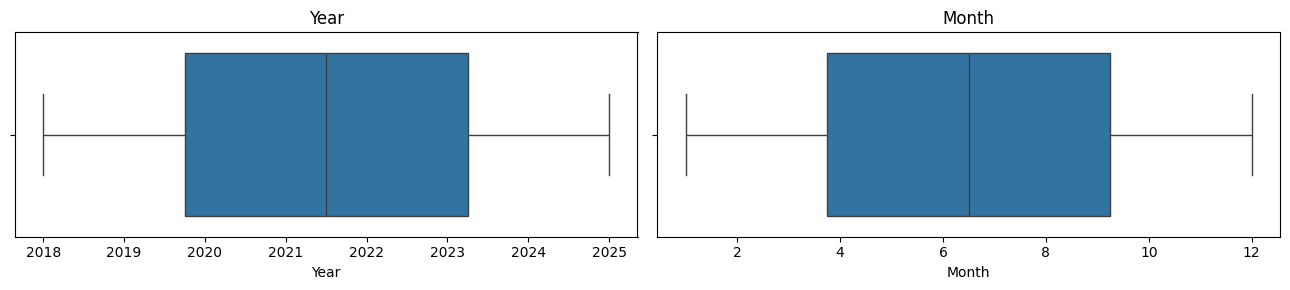

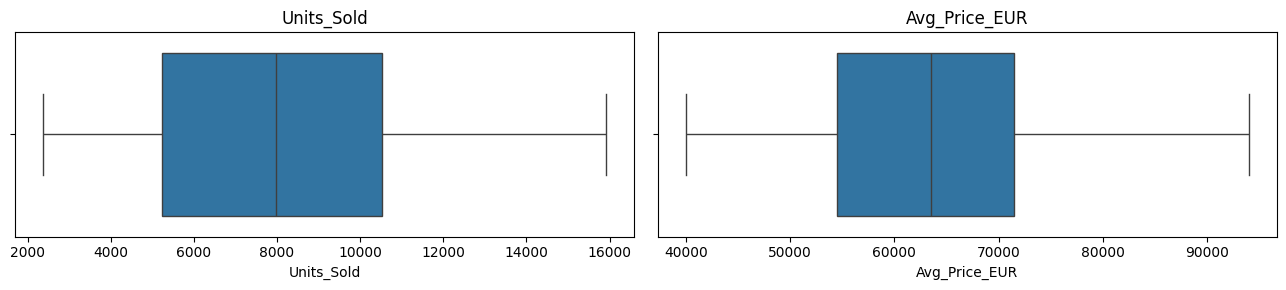

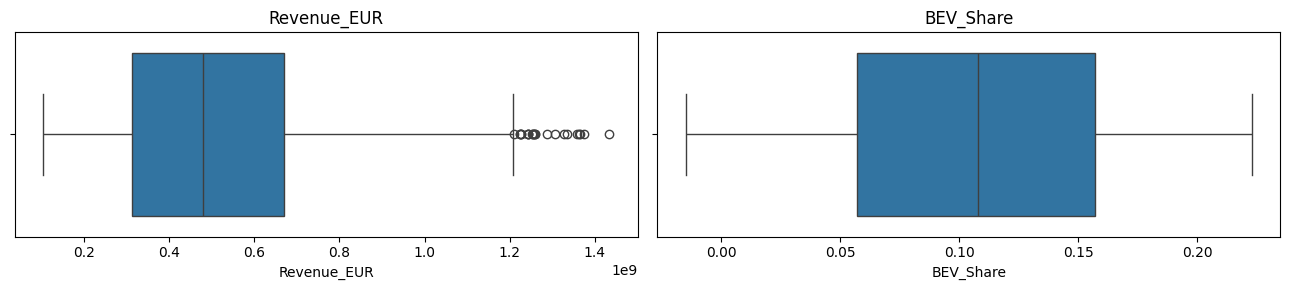

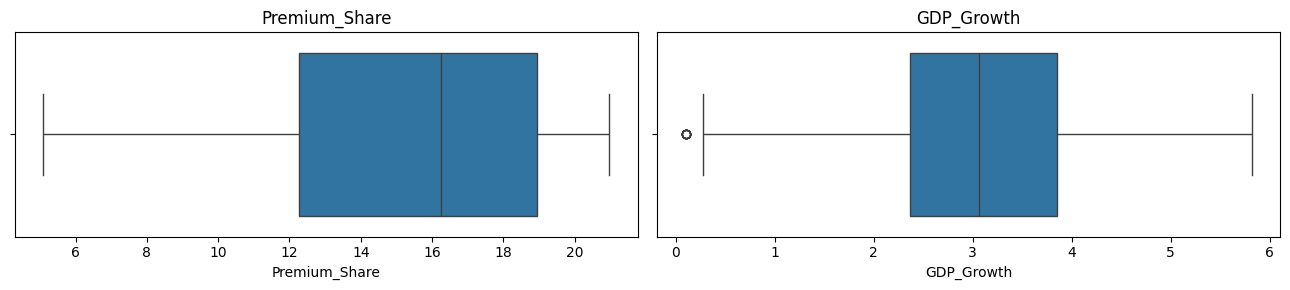

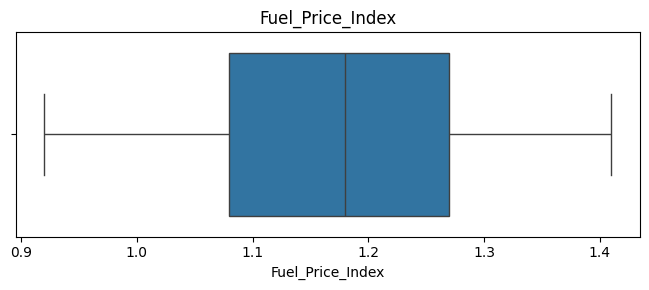

In [15]:
for i in range(0, len(num_cols), 2):
    fig = plt.figure(figsize=(13,3))

    plt.subplot(1,2,1)
    sns.boxplot(x=num_cols[i], data=df)
    plt.title(num_cols[i])

    if i+1 < len(num_cols):
        plt.subplot(1,2,2)
        sns.boxplot(x=num_cols[i+1], data=df)
        plt.title(num_cols[i+1])

    plt.tight_layout()
    plt.show()

In [16]:
for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"{col} → {len(outliers)} outliers")

Year → 0 outliers
Month → 0 outliers
Units_Sold → 0 outliers
Avg_Price_EUR → 0 outliers
Revenue_EUR → 23 outliers
BEV_Share → 0 outliers
Premium_Share → 0 outliers
GDP_Growth → 8 outliers
Fuel_Price_Index → 0 outliers
